# NEMI on fronts

Clusters fronts rather than patches.  The cutout pipeline turns images into
vectors before it can cluster them; a front is already a row of numbers, so the
CNN trunk and the patch machinery drop out and `fronts_dataloader` hands NEMI a
matrix directly.

This notebook loads the small finding run — three SURF snapshots — and
assembles the feature matrix.  See `docs/fronts_dataloader.md` for the
selection and scaling contract.

## The store

In [1]:
import numpy as np
import pandas as pd

from fronts_dataloader.fronts_dataset import FrontDataSource, RawFronts

#: The small finding run, where build-fronts' push step publishes it.  The key
#: is assembled from the run config's source block, so the products sit beside
#: the stores they were derived from:
#:     {bucket}/{folder}/{run_id}/Fronts/{build_version}/{pipeline}/fronts.zarr
STORE = ("s3://dbof/globals_for_cutouts/v2_2_01"
         "/Fronts/SMALL_DATASET/SURF/fronts.zarr")

#: Nautilus, not AWS, so the endpoint has to be given explicitly.
S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"

source = FrontDataSource(STORE, storage_options={"endpoint_url": S3_ENDPOINT})
print(f"{len(source.dates)} snapshots")
print(source.store.status().to_string(index=False))

3 snapshots
           date find group colocate
20111216_030000 done  done     done
20120104_110000 done  done     done
20120208_230000 done  done     done


What `colocate` recorded decides what the features mean: which
statistics exist at all, how wide a band each was measured over, and whether
land was dropped or propagated.

In [2]:
# What the colocate step recorded -- these decide what the features mean.
attrs = source.store.step_attrs(source.dates[0], "colocate")
for key in ("stats", "percentiles", "properties_dilation_radius",
            "properties_cross_front_radius", "dilate_only_to_front_pixels",
            "min_npix", "nan_policy"):
    print(f"  {key:30s} {attrs.get(key, '(absent)')}")

for group, columns in source.feature_groups().items():
    print(f"\n{group}  ({len(columns)} columns)")
    print("   ", ", ".join(columns[:8]), "..." if len(columns) > 8 else "")

  stats                          ['mean', 'std', 'min', 'max', 'skew']
  percentiles                    [25, 75, 90]
  properties_dilation_radius     2
  properties_cross_front_radius  0
  dilate_only_to_front_pixels    True
  min_npix                       1
  nan_policy                     omit

geometry  (12 columns)
    npix, centroid_lat, centroid_lon, length_km, orientation, num_branches, lat_min, lat_max ...

properties  (241 columns)
    npix, gradb2_mean, gradb2_std, gradb2_min, gradb2_max, gradb2_skew, gradb2_p25, gradb2_p75 ...


## Load

Every snapshot, one row per front.  Load once and `select` repeatedly — the load is the expensive half.

In [3]:
raw = RawFronts.load(source)

print(f"{len(raw):,} fronts over {len(source.dates)} snapshots")
print(raw.table.groupby("date").size().rename("fronts").to_string())

378,697 fronts over 3 snapshots
date
20111216_030000    127627
20120104_110000    127634
20120208_230000    123436


## Select features

`select` takes groups (`geometry`, `properties`, `cross`), channels
(`gradb2`, which expands to each of its statistics), or single columns, mixed
in one list.

`nan_policy="fill"` keeps every front and every feature.  `fill_value="mean"`
puts an unmeasured front at its column's centre, which asserts nothing; the
`_missing` indicator columns keep a filled value distinguishable from a
measured one.

In [20]:
# FEATURES = ["mean_curvature", "length_km", "orientation", "num_branches", "curvature_direction", ## NOTE these features create a map of abs of lat
#             "gradb2", "Theta", "Eta", "density", "gradeta2", "oceQnet", "okubo_weiss",
#             "rossby_number", "strain_mag", "strain_s", "strain_n", "wind_stress_curl"]
#
# ds = raw.select(FEATURES, stats=("mean", "std", "skew"), scaling="standardize", nan_policy="fill", div_by_f=True,
#                 fill_value="mean", missing_indicator=False)
# print(ds.summary())


#
# FEATURES = ["length_km", "num_branches"] #, "rossby_number", "strain_mag", "strain_s", "strain_n", "gradb2"] #            , "Eta", "gradeta2",orientation


# NO lat features
FEATURES = ["length_km", "num_branches", "orientation",
            "rossby_number","strain_mag", "strain_s", "strain_n", "gradb2"]


ds = raw.select(FEATURES, stats=("mean", "std", "skew"), scaling="standardize", nan_policy="fill", div_by_f=True,
                fill_value="mean", missing_indicator=False)
print(ds.summary())


# A column filled for most fronts describes the fill, not the ocean.
print("\nmost-filled columns:")
for column, info in ds.worst_filled()[:8]:
    print(f"  {column:30s} {info['n']:8,d}  {100 * info['n'] / len(ds):5.1f}%")

ds.summary()


378,697 fronts x 18 features  scaling=standardize  filled 13 columns (worst gradb2_skew 7%)  divided 6 by |f|

most-filled columns:
  gradb2_skew                      24,810    6.6%
  rossby_number_skew                  201    0.1%
  strain_mag_skew                     201    0.1%
  strain_s_skew                       201    0.1%
  strain_n_skew                       201    0.1%
  rossby_number_mean                   41    0.0%
  rossby_number_std                    41    0.0%
  strain_mag_mean                      41    0.0%


'378,697 fronts x 18 features  scaling=standardize  filled 13 columns (worst gradb2_skew 7%)  divided 6 by |f|'

`mean_curvature` is missing for 20%, and that is not "this front is straight".
The estimator needs a skeleton longer than `2 * window_size = 10` px, so every
short front comes back undefined.  Straight is measurable and comes out near
zero.

## The matrix

`X` is what `nemi.run` takes; `ids` are the same rows in the same order, so a cluster label joins back to the store on `(date, label)`.

In [21]:
print("X", ds.X.shape, ds.X.dtype, " finite:", bool(np.isfinite(ds.X).all()))
ds.to_frame().head()

#ds.to_frame().shape

#NOTE the first 4 are not included in clustering

X (378697, 18) float32  finite: True


,date,label,name,time,length_km,num_branches,orientation,rossby_number_mean,rossby_number_std,rossby_number_skew,...,strain_mag_skew,strain_s_mean,strain_s_std,strain_s_skew,strain_n_mean,strain_n_std,strain_n_skew,gradb2_mean,gradb2_std,gradb2_skew
0,20111216_030000,7657,20111216TT030000_69.5S_148.5W,2011-12-16T03:00:00,-0.538221,-0.262558,0.290128,-0.052347,-0.043743,0.634776,...,-0.163350,-0.230493,-0.679366,-1.161607,-0.105056,-0.701498,-0.260768,-1.045179,-1.259237,-1.234004
1,20111216_030000,7658,20111216TT030000_69.5S_133.6W,2011-12-16T03:00:00,-0.490311,-0.262558,1.450387,-0.032563,-0.044517,0.207970,...,-0.319290,-0.022635,-0.712679,-0.380164,0.085358,-0.721625,-0.570037,0.183993,-0.006854,0.387465
2,20111216_030000,7659,20111216TT030000_69.4S_125.7W,2011-12-16T03:00:00,-0.486777,-0.262558,-0.614486,-0.035730,-0.044922,0.282494,...,-1.437173,-0.000966,-0.682039,-0.092246,-0.035549,-0.677804,1.264370,-0.357196,-0.395849,0.578278
3,20111216_030000,7660,20111216TT030000_69.5S_101.6W,2011-12-16T03:00:00,-0.562373,-0.262558,0.946706,-0.025862,-0.044948,-0.718131,...,0.011816,-0.140123,-0.671737,1.111145,0.011231,-0.705658,0.789523,0.069027,0.166924,-0.610959
4,20111216_030000,7661,20111216TT030000_69.5S_50.6W,2011-12-16T03:00:00,-0.566558,-0.262558,1.070999,-0.037536,-0.044308,-1.085533,...,-0.818595,-0.122375,-0.730238,0.283594,-0.024943,-0.730445,1.188787,1.274694,0.443787,-0.259463


## Sweep

`run_sweep` takes the two NEMI dictionaries as grids and expands them
full-factorially.  Each embedding is fitted once and reused for every
clustering configuration on top of it, so the cost is the size of the embedding
grid, not the product of the two.

`fit_size` subsamples before fitting -- a full UMAP per cell is not what you
want while choosing parameters.

In [ ]:
from nemi_sweep.sweep import run_sweep
from visualization.sweep_plots import (plot_all_metric_heatmaps,
                                       plot_embedding_grid)

EMBEDDING_GRID = {"n_neighbors": [5], "min_dist": [0.05]}
# CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.05, 0.1, 0.5], "min_samples": [5, 10, 50, 100]}


CLUSTERING_GRID = {
    "method": ["hdbscan"],
    "min_cluster_size": [50, 100, 250, 500],
    "min_samples": [5, 25, None],
}
result = run_sweep(ds.X, EMBEDDING_GRID, CLUSTERING_GRID,
                   n_components=3, device="cpu",
                   fit_size=None, metric_sample=5_000, keep_size=50_000)


embedding {'n_neighbors': 5, 'min_dist': 0.05}
Clustering | device=cpu | {'method': 'hdbscan', 'min_cluster_size': 50, 'min_samples': 5}


/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Clusters found: 2
   method=hdbscan  min_cluster_size=50  min_samples=5  trustworthiness=0.877  continuity=0.940  normalized_stress=0.410  found_k=2  noise_%=0.170  top_cluster_%=99.934  effective_k=1.001
Clustering | device=cpu | {'method': 'hdbscan', 'min_cluster_size': 50, 'min_samples': 25}


/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [ ]:
print(result.summary())

One row per (embedding x clustering) configuration, parameters beside metrics.  `normalized_stress` and `noise_%` read lower-is-better; the rest higher.

In [ ]:
result.table.sort_values("trustworthiness", ascending=False)

## Plot

Both put the same two swept parameters on the same axes, so a heatmap cell and the scatter beneath it are the same configuration.

In [ ]:
plot_all_metric_heatmaps(result, x="n_neighbors", y="min_dist")

In [ ]:
plot_all_metric_heatmaps(result, x="min_samples", y="eps")

In [ ]:
plot_embedding_grid(result, x="n_neighbors", y="min_dist", dims=3, alpha=0.5)

In [ ]:
plot_embedding_grid(result, x="eps", y="min_samples", dims=3, alpha=0.5)

## Read the embedding

The sweep plots ask which configuration to keep.  These ask what the
kept one is organized by: same embedding, one panel per variable, so a
gradient across the cloud reads as a gradient.

The sweep stores a subsample of the rows it fitted, so anything used as
a color has to be indexed with `result.row_index` first — the plots
raise rather than silently misalign.

In [ ]:
len(result.labels)

In [ ]:
import numpy as np
from sklearn.metrics import adjusted_rand_score

idx = result.row_index                  # shared by every row's embedding

for row in range(len(result.table)):
    labels = result.labels[row]
    if labels is None:                  # that config had no clustering
        continue
    k = len(set(labels)) - (1 if -1 in labels else 0)
    hits = []
    for j, name in enumerate(ds.feature_names):
        v = ds.raw[idx, j]
        ari = adjusted_rand_score(labels, v > np.median(v))
        if ari > 0.3:
            hits.append((name, ari))
    hits.sort(key=lambda h: -h[1])
    params = dict(result.table.loc[row, list(result.swept)])
    verdict = ", ".join(f"{n} ARI {a:.2f}" for n, a in hits) or "no single column"
    print(f"row {row:2d}  {str(params):52s} {k:2d} clusters   {verdict}")

In [ ]:
from visualization.embedding_plots import (plot_embedding_by,
                                           plot_embedding_features)

best = result.table["trustworthiness"].idxmax()
E = result.embeddings[best]
print(result.table.loc[best, list(result.swept)].to_dict(), E.shape)

# centroid_lat was never selected as a feature, so it comes off the
# source table on X's rows, then down to the rows this embedding kept.
meta = ds.meta(raw.table, ["centroid_lat", "centroid_lon", 'SIarea_mean', 'gradb2_mean']).iloc[result.row_index]

plot_embedding_by(E, meta["centroid_lat"].to_numpy(), dims=3, name="centroid_lat")

In [ ]:
plot_embedding_by(E, meta['SIarea_mean'].to_numpy(), dims=2, name="ice")

In [ ]:
plot_embedding_by(E, meta['gradb2_mean'].to_numpy(), dims=2, name="grad B^2");

In [ ]:
plot_embedding_by(E, np.abs(meta["centroid_lat"].to_numpy()), name="|centroid_lat|", dims=3, alpha=0.3);

In [ ]:
ds.feature_names

A clean latitude gradient across the cloud means the embedding is a map
of where fronts are, not a taxonomy of what they are.  Most features
carry latitude — `Theta_mean` correlates with it at 0.95 — and
`div_by_f` only takes it out of the strain columns.

In [ ]:
PANELS = ["length_km", "gradb2_mean", "rossby_number_mean",
          "strain_mag_mean", "strain_n_mean", "strain_s_mean", "num_branches"]

# Unscaled values, so each colorbar reads in the variable's own units.
frame = pd.DataFrame(ds.raw, columns=ds.feature_names)[PANELS].iloc[result.row_index]
plot_embedding_features(E, frame, n_cols=3);

## NEMI runs

In [38]:
from nemi import NEMI, SingleNemi
EMBEDDING_DIMENSIONS = 3
ENSEMBLE_MEMEBERS = 3

nemi = NEMI(params={
    "device": "cpu",
    "embedding_dict":  {"n_components": 3, "n_neighbors": 5, "min_dist": 0.0},
})


# EMBEDDING ONLY
nemi.run(ds.X, n=ENSEMBLE_MEMEBERS, output="nemi_out.npz", assess_overlap=True, mode="embed", embeddings="umap.npz")

100%|██████████| 3/3 [02:27<00:00, 49.12s/it]


In [41]:
nemi = NEMI(params={
    "device": "cpu",
    "clustering_dict": {"method": "dbscan", "eps": 0.1, "min_samples":5},
})


nemi.run(output="nemi_out.npz", assess_overlap=True, mode="cluster", embeddings="umap.npz")

Loaded 3 embedding(s) from umap.npz
Embedding | device=cpu | {'n_components': 3, 'n_neighbors': 5, 'min_dist': 0.0}


  0%|          | 0/3 [00:00<?, ?it/s]

Clustering | device=cpu | {'method': 'dbscan', 'eps': 0.1, 'min_samples': 5}


 33%|███▎      | 1/3 [00:01<00:02,  1.33s/it]

Clusters found: 459
Clustering | device=cpu | {'method': 'dbscan', 'eps': 0.1, 'min_samples': 5}


 67%|██████▋   | 2/3 [00:02<00:01,  1.31s/it]

Clusters found: 544
Clustering | device=cpu | {'method': 'dbscan', 'eps': 0.1, 'min_samples': 5}


100%|██████████| 3/3 [00:03<00:00,  1.31s/it]


Clusters found: 507


Assessing overlap: 100%|██████████| 2/2 [00:00<00:00, 43.08it/s]
/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/nemi/workflow.py:501: RuntimeWarning: divide by zero encountered in log
  H = -(p * np.where(p > 0, np.log(p), 0.0)).sum(axis=0) # (N,) nats


In [43]:
d = np.load("nemi_out.npz")
print(d.files)

try :
    member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
    embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
    embedding       = d["embedding"]        # (N, d) consensus/base embedding
    entropy         = d["entropy"]
    unassigned      = d["unassigned_frac"]

    print(embeddings.shape)
    print(member_clusters.shape)
    print(clusters.shape)
    print(embedding.shape)
    print(entropy.shape)
    print(unassigned.shape)

except :
    embeddings      = d["embedding"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]

['embeddings', 'member_clusters', 'clusters', 'embedding', 'entropy', 'unassigned_frac']
(3, 378697, 3)
(3, 378697)
(378697,)
(378697, 3)
(378697,)
(378697,)


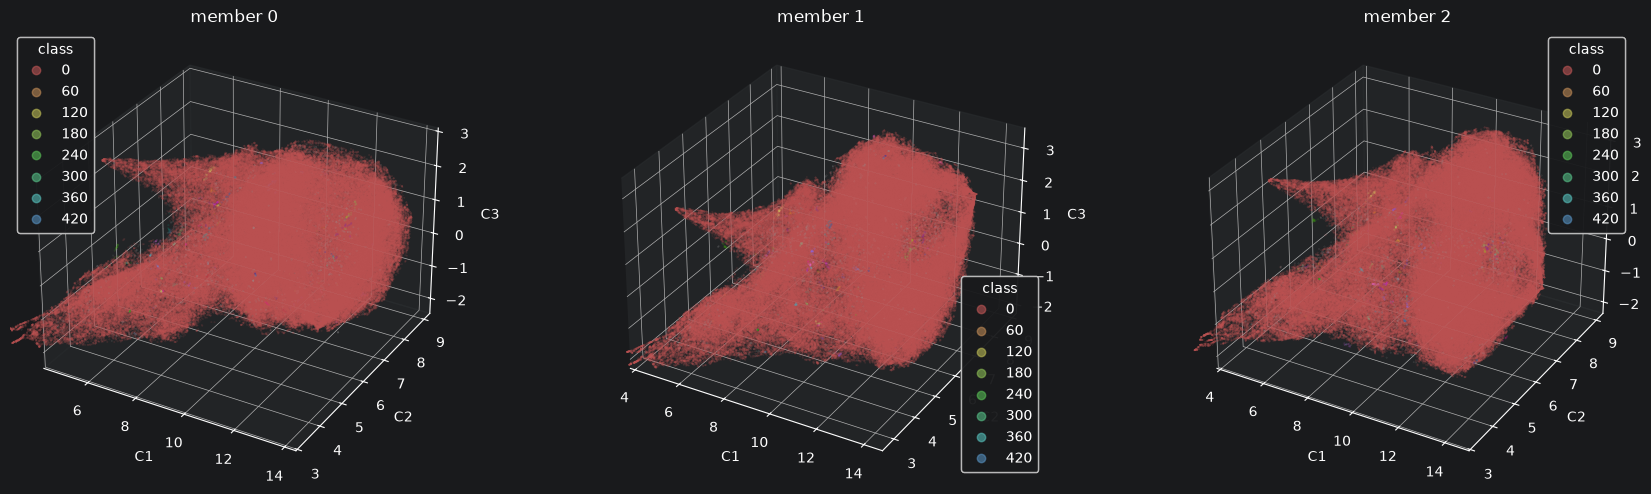

In [47]:
import visualization.visualization as vis

alpha = 0.5
#labeled by consensus cluster
if ENSEMBLE_MEMEBERS > 1:
    vis.vis_dim_redux_list(embeddings, labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(embeddings))], alpha=alpha)
else:
    vis.vis_dim_redux(embeddings, labels=clusters, label_title="clusters", dims=EMBEDDING_DIMENSIONS, alpha=alpha)